# Вспомогательные расчёты

<div class='alert alert-info'>

Здесь выполнены некоторые дополнительные расчёты, важные для принятия решений о ходе моделирования и для интерпретации данных. 

Сами по себе они большого значения не имеют, и помещать их в `train_model.ipynb` или в `prediction.ipynb` не стоит. Но, так как они имеют принципиальное значение в некоторых моментах, провести их следует.

</div>

## 1. Подготовка к работе

### 1.1. Импорт библиотек и функций

In [ ]:
import os
import pickle
import sys
import warnings

import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd 
from scipy import stats
import seaborn as sns
import shap
import xgboost as xgb


### 1.2. Установка значений некоторых опций и констант

In [2]:
# Нужно, чтобы при отладке не перезапускать ноутбук каждый раз 
# после внесения правок в скрипт. 
%load_ext autoreload
%autoreload 2

In [3]:
# для улучшения читаемости проекта запретим показывать предупреждения
warnings.filterwarnings("ignore")

In [84]:
# загрузить конфиг
with open('C:/Users/user/Yandex.Disk/Важные документы/Исходные данные для статей/Моделирование вспышек/Моделирование ареала пихты/Abies_01/config.json', 'r', encoding='utf-8') as f:
    config = json.load(f)

# имя модели, используемой в работе
MODEL_NAME = config['MODEL_NAME']
# путь к выбранной модели
MODEL_PATH = config['MODEL_PATH']
# загрузить названия файлов с данными по пихте и прочим лесообразователям
NAME_ABIES_FILE = config['NAME_ABIES_FILE']
NAME_OTHERSP_FILE = config['NAME_OTHERSP_FILE']
# адрес корневой папки
ROOT_DIR = config['ROOT_DIR']
# зерно для генератора случайных чисел
SEED = config['SEED']


In [5]:
# нужно для уверенной загрузки скриптов из папки 'scripts'
scripts_path = os.path.join(ROOT_DIR, "scripts")

if scripts_path not in sys.path:
    sys.path.append(scripts_path)


## 2. Загрузка данных

In [6]:
from load_weather_partially import load_weather_partially
from calculate_weather_data import calculate_weather_data


In [7]:
data_abies, data_not_abies = load_weather_partially()

Загрузка данных из predictors_abies.txt:   0%|          | 0/4548 [00:00<?, ?it/s]

Объём данных для загрузки по пихтовым древостоям: 4548.


Загрузка данных из predictors_not_abies.txt:   0%|          | 0/56892 [00:00<?, ?it/s]

Объём данных для загрузки по прочим древостоям: 56892.
Количество загруженных столбцов данных для пихты совпадает с исходным файлом.
Количество загруженных столбцов данных для прочих сообществ совпадает с исходным файлом.
Названия столбцов загруженных наборов данных совпадают.
Дублирующихся строк в наборе данных по пихте нет.
Дублирующихся строк в наборе данных по другим сообществам нет.


In [8]:
data_abies_g, data_not_abies_g = calculate_weather_data(
    data_abies=data_abies, data_not_abies=data_not_abies
    )

In [9]:
del data_abies, data_not_abies

## 3. Исследование корреляций характеристик погоды и рельефа

![clusters](eda/feature_clusters.jpeg)


<div class='alert alert-info'>

Нужно проанализировать связи для 

- осадков января (`pre_01`) внутри левого зелёного кластера; 
- осадков мая (`pre_05`) и высоты н.у.м. (`srtm`) внутри фиолетового кластера; 
- влажности воздуха сентября (`rel_hum_09`) и глубины снега октября (`snow_depth_10`) внутри красного кластера; 
- эвапорации марта (`evap_03`) и апреля (`evap_04`) внутри коричневого кластера; 
- содержания воды в почве в марте (`soil_water_03`) внутри левого серого кластера. 

</div>

### 3.1. Левый зелёный кластер

In [10]:
features = ['pre_01', 'pre_11', 'pre_02', 'pre_12']

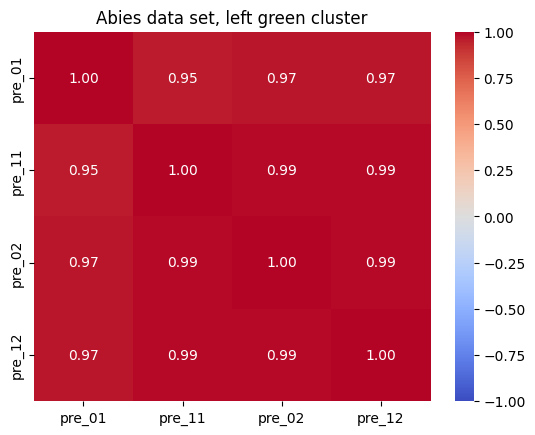

In [11]:
sns.heatmap(data_abies_g.loc[:, features].corr(), vmin=-1, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Abies data set, left green cluster')
plt.show()

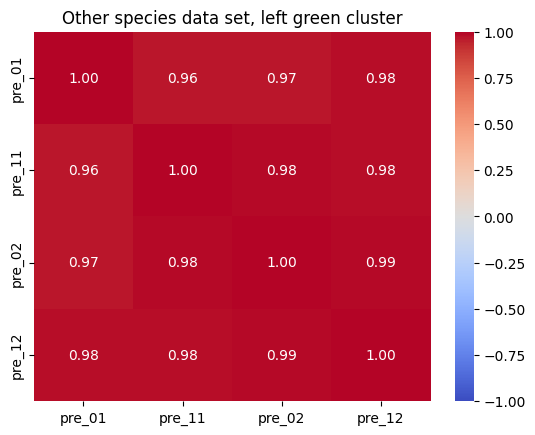

In [12]:
sns.heatmap(data_not_abies_g.loc[:, features].corr(), vmin=-1, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Other species data set, left green cluster')
plt.show()

### 3.2. Фиолетовый кластер

In [13]:
features = ['srtm', 'slope', 'pre_07', 'pre_06', 'pre_08', 'pre_09', 'pre_04', 'pre_05']

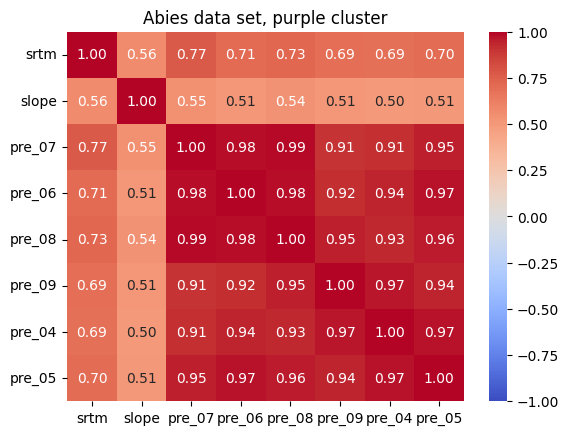

In [14]:
sns.heatmap(data_abies_g.loc[:, features].corr(), vmin=-1, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Abies data set, purple cluster')
plt.show()

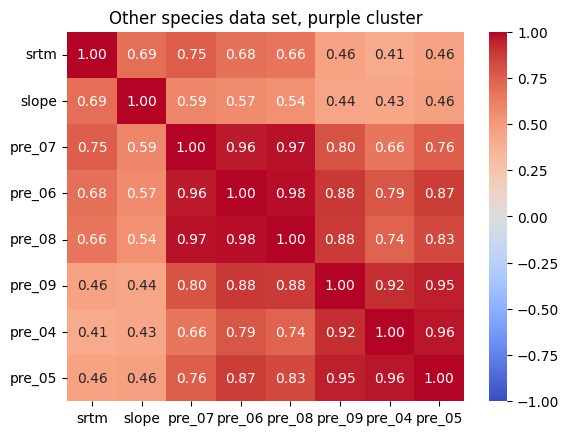

In [15]:
sns.heatmap(data_not_abies_g.loc[:, features].corr(), vmin=-1, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Other species data set, purple cluster')
plt.show()

### 3.3. Красный кластер

In [16]:
features = [
    'snow_depth_10', 'snow_depth_11', 'snow_depth_04', 'snow_depth_12', 
    'rel_hum_09', 'rel_hum_05', 'rel_hum_08', 'rel_hum_06', 'rel_hum_07'
    ]

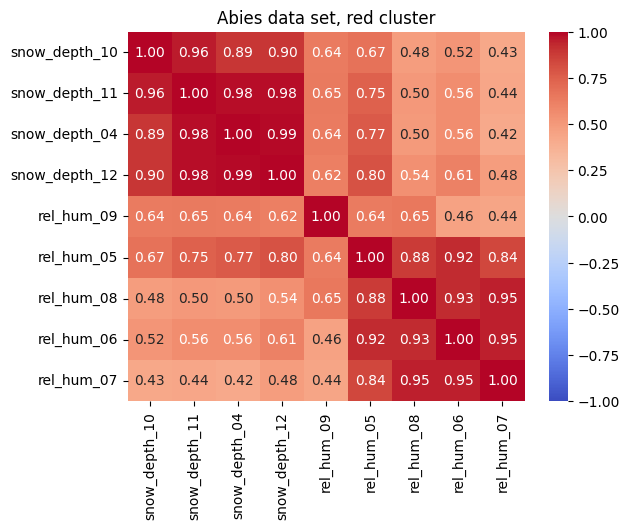

In [17]:
sns.heatmap(data_abies_g.loc[:, features].corr(), vmin=-1, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Abies data set, red cluster')
plt.show()

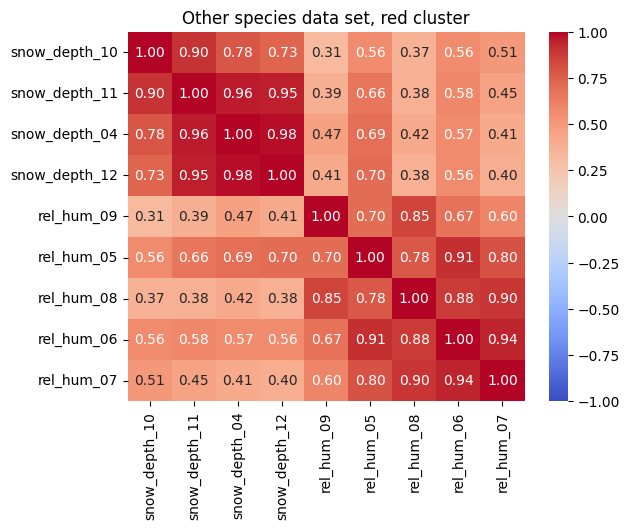

In [18]:
sns.heatmap(data_not_abies_g.loc[:, features].corr(), vmin=-1, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Other species data set, red cluster')
plt.show()

### 3.4. Коричневый кластер

In [19]:
features = [
    'evap_03', 'evap_02', 'evap_01', 'evap_12', 'evap_10', 'evap_11', 'evap_04', 'evap_05'
    ]

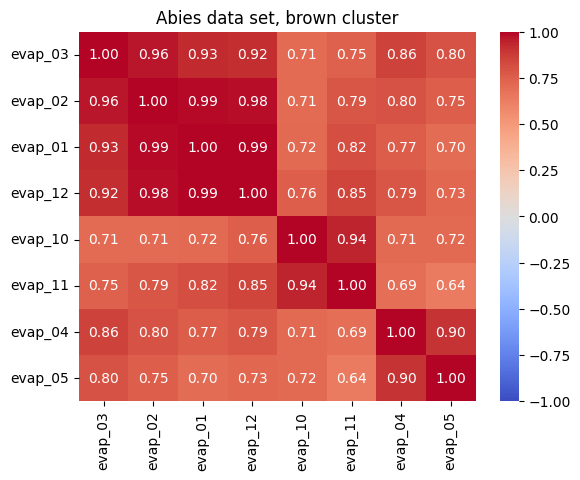

In [20]:
sns.heatmap(data_abies_g.loc[:, features].corr(), vmin=-1, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Abies data set, brown cluster')
plt.show()

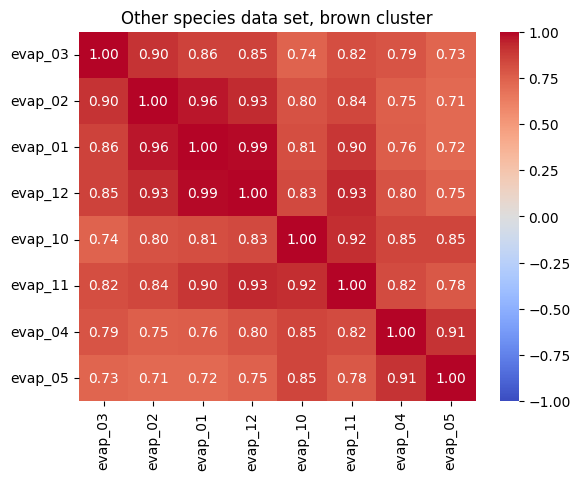

In [21]:
sns.heatmap(data_not_abies_g.loc[:, features].corr(), vmin=-1, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Other species data set, brown cluster')
plt.show()

### 3.5. Левый серый кластер

In [22]:
features = [
    'soil_water_10', 'soil_water_11', 'soil_water_12', 'soil_water_04', 'soil_water_03', 'soil_water_01', 'soil_water_02'
    ]

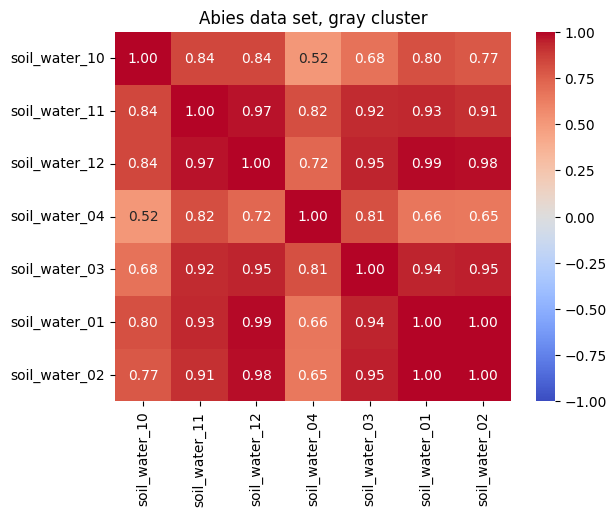

In [23]:
sns.heatmap(data_abies_g.loc[:, features].corr(), vmin=-1, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Abies data set, gray cluster')
plt.show()

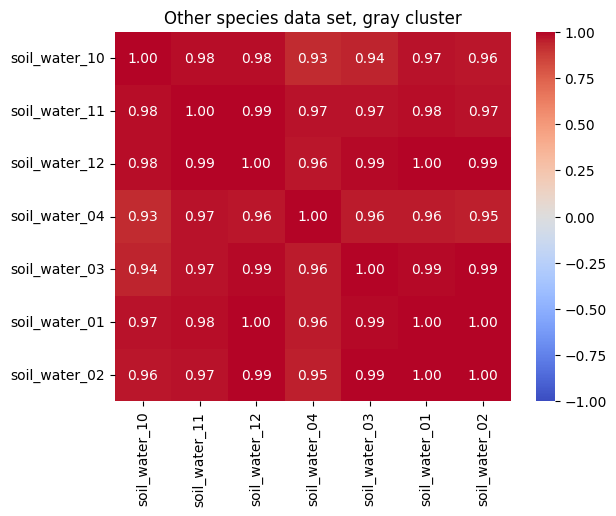

In [24]:
sns.heatmap(data_not_abies_g.loc[:, features].corr(), vmin=-1, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Other species data set, gray cluster')
plt.show()

### 3.6. Предикторы модели

In [25]:
features = [
    'pre_01', 'pre_05', 'rel_hum_09', 'snow_depth_10', 'evap_03', 'soil_water_03', 'evap_04', 'srtm'
    ]

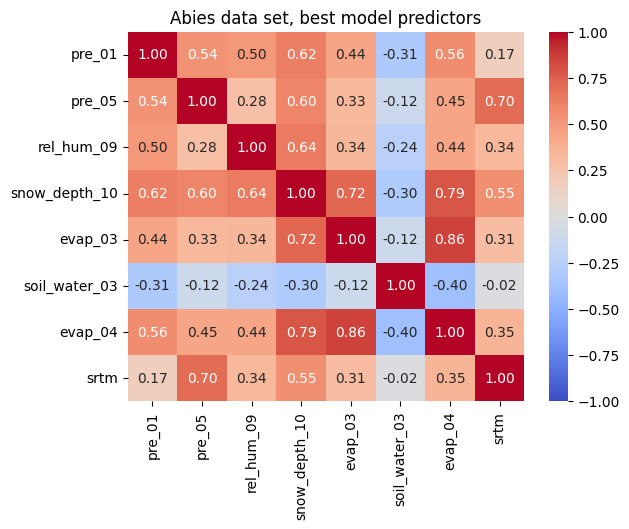

In [26]:
sns.heatmap(data_abies_g.loc[:, features].corr(), vmin=-1, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Abies data set, best model predictors')
plt.show()

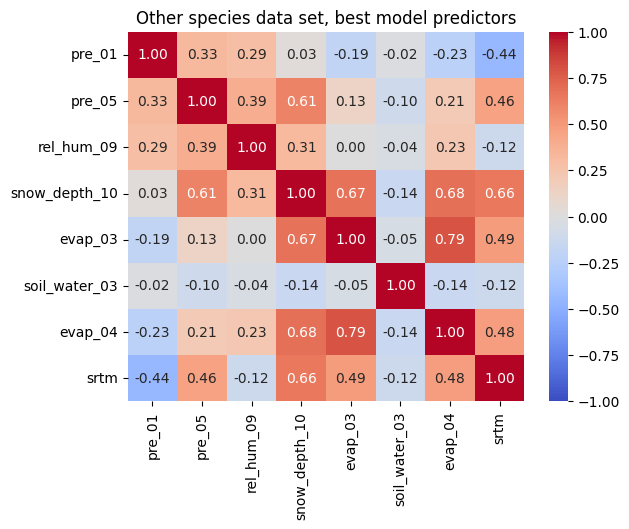

In [27]:
sns.heatmap(data_not_abies_g.loc[:, features].corr(), vmin=-1, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Other species data set, best model predictors')
plt.show()

## 4. Детальный анализ связи глубины снега с другими предикторами

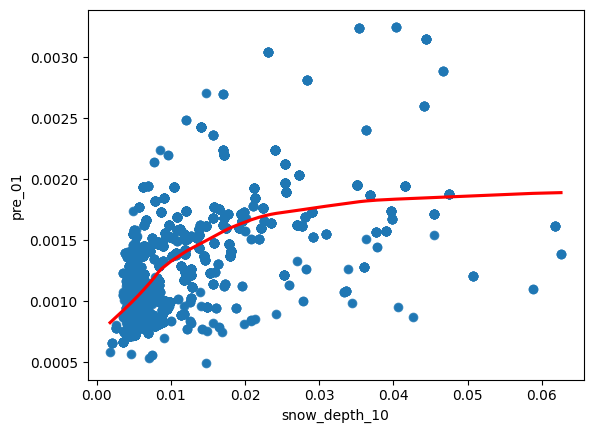

In [28]:
sns.scatterplot(data=data_abies_g, x='snow_depth_10', y='pre_01')
sns.regplot(data=data_abies_g, x='snow_depth_10', y='pre_01', lowess=True, line_kws={'color': 'red'})
plt.show()

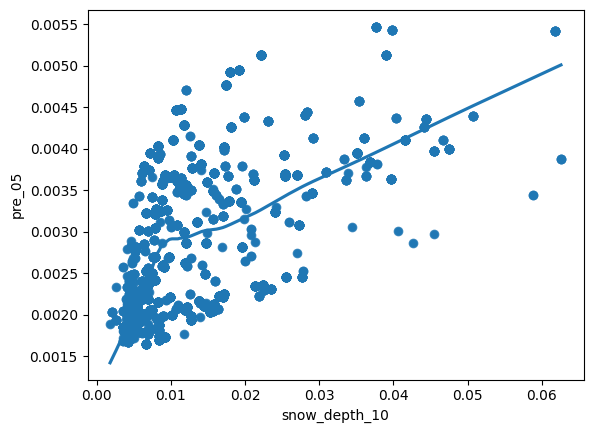

In [29]:
sns.scatterplot(data=data_abies_g, x='snow_depth_10', y='pre_05')
sns.regplot(data=data_abies_g, x='snow_depth_10', y='pre_05', lowess=True)
plt.show()

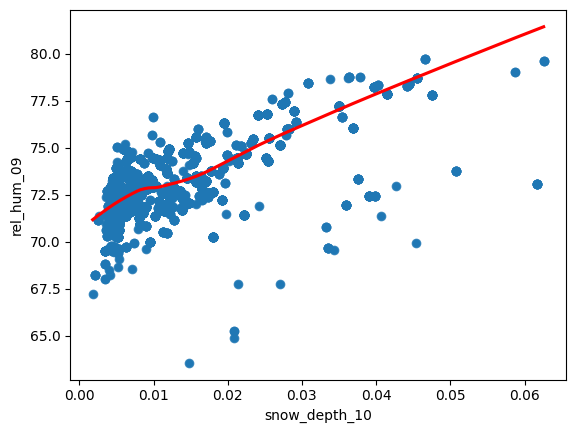

In [30]:
sns.scatterplot(data=data_abies_g, x='snow_depth_10', y='rel_hum_09')
sns.regplot(data=data_abies_g, x='snow_depth_10', y='rel_hum_09', lowess=True, line_kws={'color': 'red'})
plt.show()

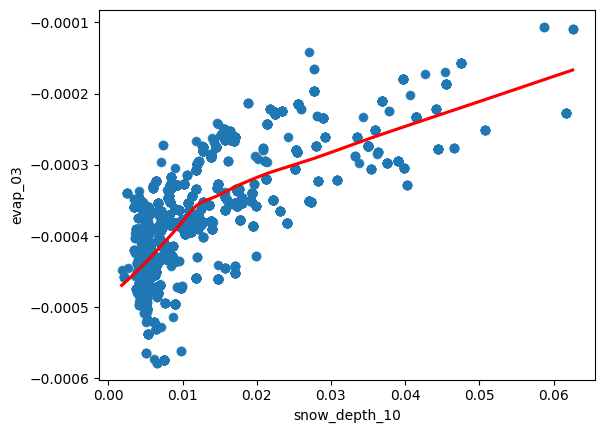

In [31]:
sns.scatterplot(data=data_abies_g, x='snow_depth_10', y='evap_03')
sns.regplot(data=data_abies_g, x='snow_depth_10', y='evap_03', lowess=True, line_kws={'color': 'red'})
plt.show()

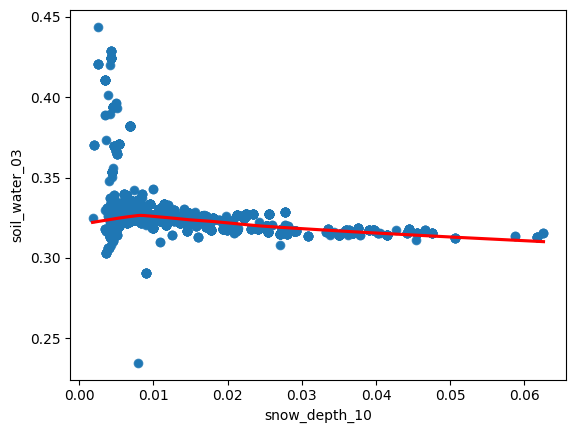

In [32]:
sns.scatterplot(data=data_abies_g, x='snow_depth_10', y='soil_water_03')
sns.regplot(data=data_abies_g, x='snow_depth_10', y='soil_water_03', lowess=True, line_kws={'color': 'red'})
plt.show()

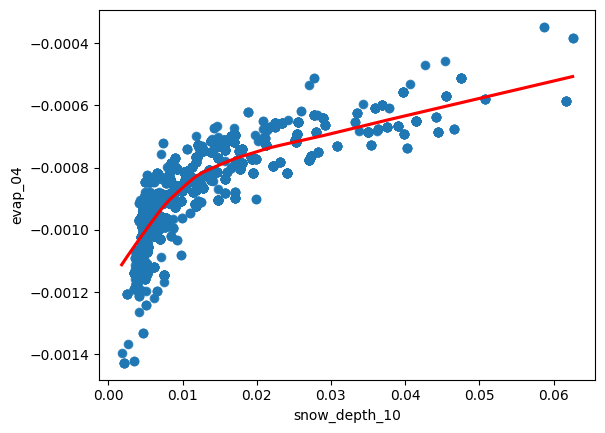

In [33]:
sns.scatterplot(data=data_abies_g, x='snow_depth_10', y='evap_04')
sns.regplot(data=data_abies_g, x='snow_depth_10', y='evap_04', lowess=True, line_kws={'color': 'red'})
plt.show()

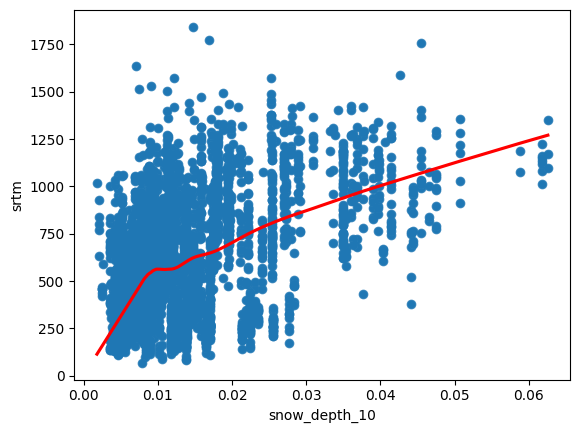

In [34]:
sns.scatterplot(data=data_abies_g, x='snow_depth_10', y='srtm')
sns.regplot(data=data_abies_g, x='snow_depth_10', y='srtm', lowess=True, line_kws={'color': 'red'})
plt.show()

## 5. Дополнительный анализ динамики изменения глубины снежного покрова в историческое время

<div class='alert alert-warning'>

Этот раздел нужен, т.к. разведочный анализ показал очень сильное отклонение прогнозных данных о глубине снежного покрова октября от исторических. Это очень значительно влияло на результаты прогнозирования судьбы пихтовых древостоев. У меня возникло опасение, что это произошло из-за ошибок конвертации одних единиц измерения в другие (см. пояснение в начале этого раздела). 

Поэтому я считаю нужным проверить, не является ли прогнозируемое снижение глубины снега продолжением уже имеющегося тренда. Если так, то это подтвердит корректность пересчёта. 

</div>

In [35]:
# Предварительно исследуем тренд изменения глубины снега в октябре, 
# усреднив данные по всей территории. 

# загрузим данные о глубине снежного покрова в историческое время
snow_depth_in_dynamics = pd.read_csv(os.path.join(ROOT_DIR, 'data', 'snow_depth_1940_2025.txt'))
# Рассчитаем среднюю по территории глубину снежного покрова; 
# использование iloc нужно, чтобы убрать первые столбцы с id и координатами. 
mean_snow_depth_by_years = snow_depth_in_dynamics.iloc[:, 3:89].mean(axis=0)
# получим агрумент для регрессионного  анализа (последовательность чисел от 0 [начальный год] до 85)
years = np.arange(len(mean_snow_depth_by_years))

# выполним линейную регрессию
slope, intercept, r_value, p_value, std_err = stats.linregress(years, mean_snow_depth_by_years)

# выведем линейный коэффициент и уровень значимости регрессии
print(f'Линейный коэффициент для глубины снега в октябре: {slope:.2e}. \n')
print(f'Уровень значимости линейного тренда глубины снега в октябре: {p_value:.3f}. \n')

Линейный коэффициент для глубины снега в октябре: -4.65e-05. 

Уровень значимости линейного тренда глубины снега в октябре: 0.011. 



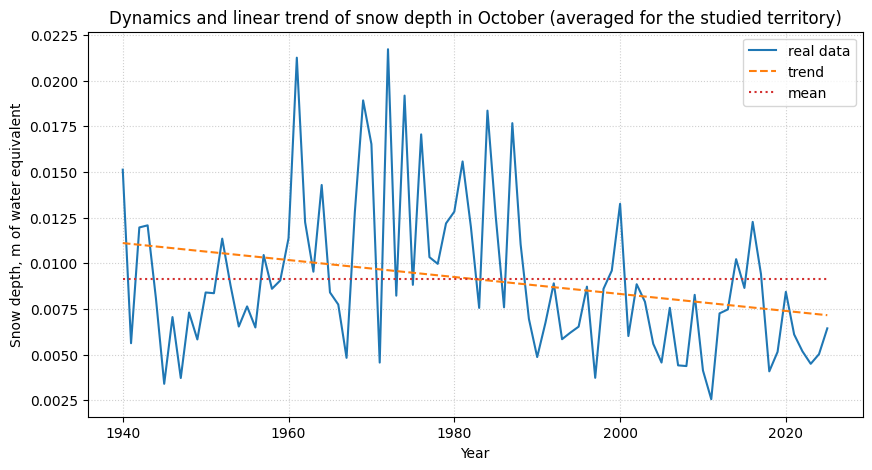

In [36]:
# Проанализируем полученный выше результат графически

# создадим фрейм, нужный как исходник для построения графика
snow_depth_in_dynamics_trend = pd.DataFrame(
    {
        # реальные данные о глубине снега
        'real data': mean_snow_depth_by_years, 
        # линия тренда
        'trend': slope * years + intercept
    }
    )
# в качестве индексов добавим годы
snow_depth_in_dynamics_trend.index = np.arange(1940, 2026)

# строим график встроенным методом pandas .plot()
ax = snow_depth_in_dynamics_trend[['real data', 'trend']].plot(
    figsize=(10, 5), 
    color=['#1f77b4', '#ff7f0e'], 
    style=['-', '--'] 
)

# настраиваем подписи
# заголовок графика
ax.set_title("Dynamics and linear trend of snow depth in October (averaged for the studied territory)")
# подпись оси абсцисс
ax.set_xlabel("Year")
# подпись оси ординат
ax.set_ylabel("Snow depth, m of water equivalent")
# добавим горизонтальную линию, указывающую среднемноголетнее значение
ax.hlines(
    snow_depth_in_dynamics_trend['real data'].mean(), 
    xmin=1940, 
    xmax=2025, 
    color='#D32F2F', 
    linestyle=':', 
    label='mean'
    )
# добавим сетку
ax.grid(True, linestyle=':', alpha=0.6)
# добавим легенду
ax.legend(loc='upper right', frameon=True)

# выведем график
plt.show()


In [37]:
# разделим данные о глубине снежного покрова на собственно эти данные и координаты
snow_depth_in_dynamics_data = snow_depth_in_dynamics.iloc[:, 3:89]
snow_depth_in_dynamics_coord = snow_depth_in_dynamics.iloc[:, 1:3]

In [38]:
# рассчитаем линейные коэффициенты для каждого полигона
slopes = snow_depth_in_dynamics_data.apply(
    lambda row: stats.linregress(years, row.values).slope, axis=1
    )
# рассчитаем уровни значимости регрессии для каждого полигона
p_values = snow_depth_in_dynamics_data.apply(
    lambda row: stats.linregress(years, row.values).pvalue, axis=1
    )

In [39]:
# Создадим фрейм с исходными данными для создания карты. На карте будет показано, 
# на каких полигонах глубина снега в октябре статистически значимо возрастала 
# в исторический период, а на каких снижалась. Отдельно будут показаны полигоны, 
# где линейный тренд был незначим статистически. 

# создание фрейма
snow_depth_trends = pd.DataFrame(
    {
        # линейные коэффициенты для каждого полигона
        'slopes': slopes, 
        # уровни значимости тренда
        'p_values': p_values
    }
)

# создадим список условий для оценки направления и значимости тренда
conditions = [
    (snow_depth_trends['slopes'] > 0) & (snow_depth_trends['p_values'] <= 0.05), 
    (snow_depth_trends['slopes'] < 0) & (snow_depth_trends['p_values'] <= 0.05)
    ]
# зададим метки, описывающие направление значимых трендов
labels = ['positive', 'negative']

# Добавим столбец с данными о направлении изменений 
# (для незначимых добавим дефолтную метку 'non-significant'). 
snow_depth_trends['direction'] = np.select(conditions, labels, default='non-significant')
# добавим столбцы с координатами
snow_depth_trends['lat'] = snow_depth_in_dynamics_coord['POINT_Y']
snow_depth_trends['lon'] = snow_depth_in_dynamics_coord['POINT_X']

In [40]:
# Выведем сообщение о количестве полигонов 
# со статистически значимым увеличением и снижением глубины снега в октябре. 
print(
    f"Количество полигонов со статистически значимым возрастанием глубины снежного покрова в октябре: "
    f"{snow_depth_trends.query('slopes > 0 and p_values <= 0.05').shape[0]} из {snow_depth_trends.shape[0]}. \n"
    )
print(
    f"Количество полигонов со статистически значимым возрастанием глубины снежного покрова в октябре: "
    f"{snow_depth_trends.query('slopes < 0 and p_values <= 0.05').shape[0]} из {snow_depth_trends.shape[0]}. \n"
    )

Количество полигонов со статистически значимым возрастанием глубины снежного покрова в октябре: 590 из 60484. 

Количество полигонов со статистически значимым возрастанием глубины снежного покрова в октябре: 32856 из 60484. 



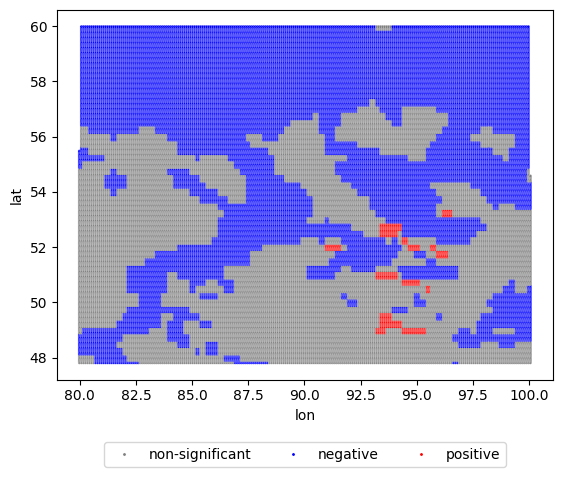

In [41]:
# создадим график-карту
ax = sns.scatterplot(
    snow_depth_trends, 
    x='lon', 
    y='lat', 
    hue='direction', 
    palette={'positive': 'red', 'negative': 'blue', 'non-significant': 'gray'},
    s=5
)
# добавим легенду
ax.legend(
    loc='upper center',             # Точка привязки внутри самой легенды (верхний центр)
    bbox_to_anchor=(0.5, -0.15),    # Координаты размещения (X=центр графика, Y=ниже нижней оси)
    ncol=3,                         # Размещаем элементы в 3 столбца, чтобы они шли горизонтально
    frameon=True                    # Оставляем рамку, если необходимо
)
plt.show()

<div class='alert alert-success'>

По итогу можно сказать, что низкие значения глубины снега при любом сценарии SSP – продолжение уже имеющейся тенденции. Таким образом, за качество конвертации данных о глубине снега из одних единиц в другие можно быть спокойным. 

</div>

In [42]:
del ax, conditions, intercept, labels, mean_snow_depth_by_years, p_value, p_values, r_value
del slope, slopes, snow_depth_in_dynamics, snow_depth_in_dynamics_trend, 
del snow_depth_in_dynamics_coord, snow_depth_in_dynamics_data, 
del snow_depth_trends, std_err, years

## 6. SHAP-анализ

In [124]:
from shap_calc import shap_calc

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

  0%|          | 0/10237 [00:00<?, ?it/s]

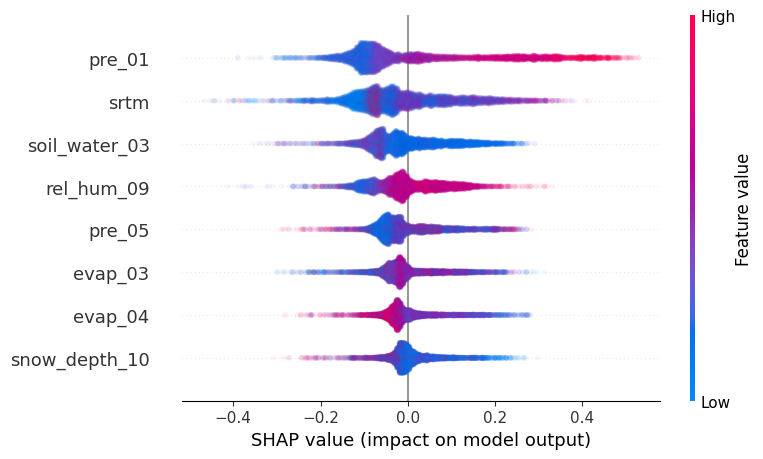

In [126]:
shap_values = shap_calc(
    data_abies=data_abies_g, 
    data_other=data_not_abies_g, 
    model_file='abies_area_model_2026_07_01_14_33_fbeta', 
    model_path='models/abies_area_model_fbeta_0.7', 
    shap_values=None, 
    mode='beeswarm'
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

<Figure size 800x500 with 0 Axes>

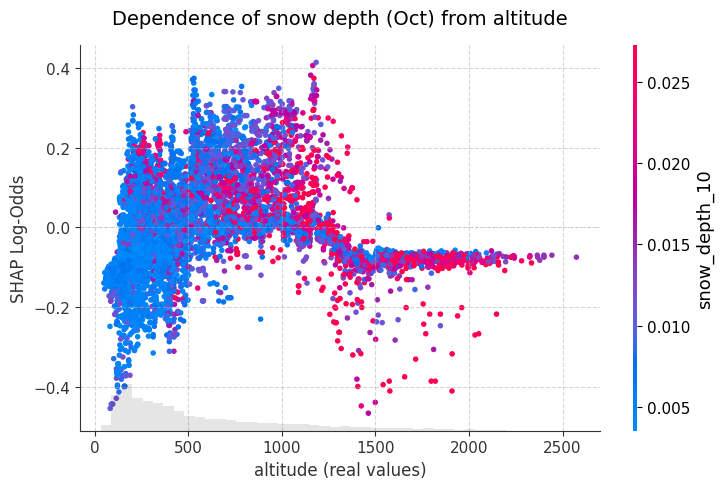

In [128]:
shap_values = shap_calc(
    data_abies=data_abies_g, 
    data_other=data_not_abies_g, 
    model_file='abies_area_model_2026_07_01_14_33_fbeta', 
    model_path='models/abies_area_model_fbeta_0.7', 
    shap_values=shap_values, 
    mode='scatter', 
    feature1='srtm', 
    feature2='snow_depth_10', 
    feature_name1='altitude', 
    feature_name2='snow depth (Oct)'
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

<Figure size 800x500 with 0 Axes>

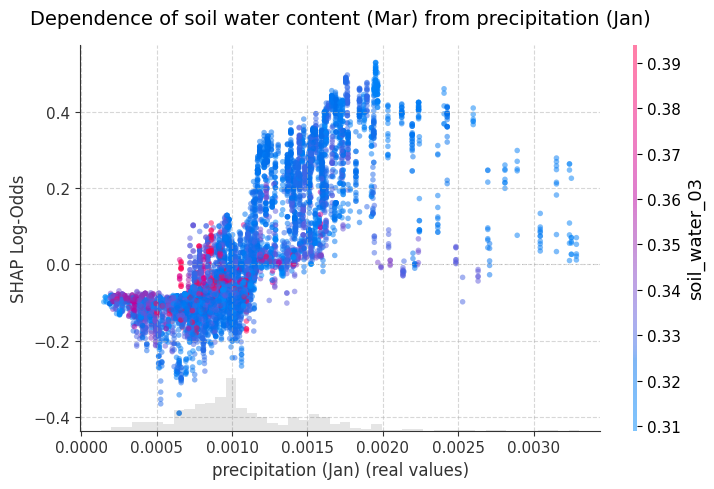

In [134]:
shap_values = shap_calc(
    data_abies=data_abies_g, 
    data_other=data_not_abies_g, 
    model_file='abies_area_model_2026_07_01_14_33_fbeta', 
    model_path='models/abies_area_model_fbeta_0.7', 
    shap_values=shap_values, 
    mode='scatter', 
    feature1='pre_01', 
    feature2='soil_water_03', 
    feature_name1='precipitation (Jan)', 
    feature_name2='soil water content (Mar)'
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

<Figure size 800x500 with 0 Axes>

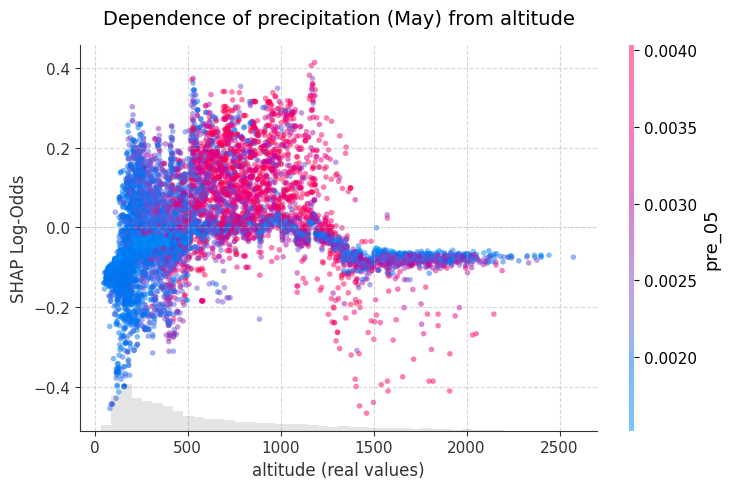

In [139]:
shap_values = shap_calc(
    data_abies=data_abies_g, 
    data_other=data_not_abies_g, 
    model_file='abies_area_model_2026_07_01_14_33_fbeta', 
    model_path='models/abies_area_model_fbeta_0.7', 
    shap_values=shap_values, 
    mode='scatter', 
    feature1='srtm', 
    feature2='pre_05', 
    feature_name1='altitude', 
    feature_name2='precipitation (May)'
)

In [136]:
stats.pearsonr(data_abies_g['pre_01'], data_abies_g['soil_water_03'])

PearsonRResult(statistic=-0.3055286622463894, pvalue=7.078196517709924e-99)

## Контроль объектов в памяти

In [ ]:
%whos